In [ ]:
"""Inserts"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Any, Callable


### Test

In [ ]:
"""Reading data"""
training_data=pd.read_parquet("data_parquet_2026/train.parquet")
sensors = pd.read_parquet("data_parquet_2026/sensors.parquet").drop_duplicates
test_data = pd.read_parquet("data_parquet_2026/test.parquet")


In [ ]:
""" Ségrégation des profiles"""
n=int(len(training_data["power"])/len(training_data["sensor"].unique())/3) #27384/3 = 9128
power1 = training_data.query("sensor =='N0000'")
power2 = training_data.query("sensor =='N0000'")
power3 = training_data.query("sensor =='N0000'")

for senso in training_data["sensor"].unique():
    power1 = pd.concat((power1, training_data[training_data["sensor"] == senso][:n]))
    power2 = pd.concat((power2, training_data[training_data["sensor"] == senso][n+1:2*n]))
    power3 = pd.concat((power3, training_data[training_data["sensor"] == senso][2*n+1:]))

#power1.plot.scatter(x="time", y="power", alpha=0.5)
#power2.plot.scatter(x="time", y="power", alpha=0.5)
#power3.plot.scatter(x="time", y="power", alpha=0.5)

In [ ]:
#for sens in training_data["sensors"]:
 #   print(sens)
sampleP=training_data.query("sensor=='N418' and 0< temperature<35 and time < 1e8")
sampleP.plot.scatter(x="time", y="temperature", alpha=0.5)
#mean.plot.scatter(x="time", y="temperature", alpha=0.5)

In [ ]:
"""graphes tous pour 1 senseur"""

sampleN418 = power3

#sampleN418.plot.scatter(x="time", y="power", alpha=0.5)
#sampleN418.query("-100 < temperature < 200").plot.scatter(x="time", y="temperature", alpha=0.5)
#sensors.query("sensor == 'N418'")
sampleN418["time"]= sampleN418["time"]/864000
sampleN418.tail()


In [ ]:
b = training_data.query("time <= 10**9 and time >= 0.8*10**9")
b.plot.scatter(x="time", y="power", alpha=0.5)
b.plot.scatter(x="time", y="temperature", alpha=0.5)



In [ ]:
#for sens in training_data["sensors"]:
 #   print(sens)
sampleP=training_data.query("time <= 1800000 and sensor=='N418'")
sampleP.head(10)

sampleP.plot.scatter(x="power", y="temperature", alpha=0.5)
#mean.plot.scatter(x="time", y="temperature", alpha=0.5)

In [ ]:
a = sampleP["power"].diff(periods=864000)

a.head(20)
power1 = training_data.query("power == 500.0000 or power == 1000.0000 or power == 1500.0000")
power1.plot.scatter(x="time", y="power", alpha=0.5)


In [ ]:
"""graphes tous pour 1 senseur"""

sampleN418 = training_data.query(" sensor=='N418'")
sampleN418.plot.scatter(x="time", y="power", alpha=0.5)
sampleN418.plot.scatter(x="power", y="temperature", alpha=0.5)
sensors.query("sensor == 'N418'")

In [ ]:
b = training_data.query("time <= 10**9 and time >= 0.8*10**9")
b.plot.scatter(x="time", y="power", alpha=0.5)
b.plot.scatter(x="time", y="temperature", alpha=0.5)
c=b["power"].pct_change(periods=1)


In [ ]:
sampleN418b = sampleN418.sample(1000)
sampleN418b.plot.scatter(x="time", y="power", alpha=0.5)
sampleN418b.plot.scatter(x="time", y="temperature", alpha=0.5)


## I. First Model: KNN Method

### 1. Distance Metrics

In [ ]:
def man_dist(sample_coo: pd.DataFrame, train_set_coo: pd.DataFrame) -> pd.DataFrame:

    """Computes the Manhattan distance between a sample and all train sensors, and add
    their values in a new column of train_set_coo.
    Args:
        sample_coo: Dataset of the sample's coordinates
        train_set_coo: Dataset of the sensors' coordinates
    Returns:
        train_set_coo_with_dist: train_set_coo with a column "distance", filled.
    """

    coor_train = np.array([train_set_coo["coor_x"], train_set_coo["coor_y"]]).T
    coor_sample = np.array([sample_coo["coor_x"], sample_coo["coor_y"]])

    train_set_coo["distance"] = np.abs(coor_train - coor_sample).sum(axis = 1)

    return train_set_coo
   


def eucli_dist(sample_coo: pd.DataFrame, train_set_coo: pd.DataFrame) -> pd.DataFrame:

    """Computes the Euclidian distance between a sample and all train sensors, and add
    their values in a new column of train_set_coo.
    Args:
        sample_coo: Dataset of the sample's coordinates
        train_set_coo: Dataset of the sensors' coordinates
    Returns:
        train_set_coo_with_dist: train_set_coo with a column "distance", filled.
    """
    
    coor_train = np.array([train_set_coo["coor_x"], train_set_coo["coor_y"]]).T
    coor_sample = np.array([sample_coo["coor_x"], sample_coo["coor_y"]])

    train_set_coo["distance"] = np.sqrt(((coor_train - coor_sample) ** 2).sum(axis = 1))

    return train_set_coo


### 2. Distance Score

In [ ]:
def distance_score(neighbors:pd.DataFrame,
                   score_parameter: float = 1) -> pd.DataFrame:
    
    """Replace the "distance" column by a "score" one to each given neighbor sensor,
    depending on their distance to the sample.
    The closer is the sample, the higher the score. We set an upper limit to it
    to avoid giving "blind confidence" to "very close" sensors.
    Args:
        neighbors: neighbor sensors, with "distance" column, regarding the sample.
        score_parameter: Hyper-parameter, set to 1 by default.
    Returns:
        neighbors: Updated with the "score" column.
    """

    scores = 1 / (score_parameter * neighbors["distance"] + 1)

    # We replace the distance column (which we don't need anymore) by the "score" one.
    neighbors["score"] = scores
    neighbors.drop(labels = ["distance"], axis = 1, inplace = True)
    
    return neighbors

### 3. Missing Values / Outliers managers A COMPLETER (docu)

In [52]:
def window_cleaning(rows: pd.DataFrame, margin: float = 1.5) -> pd.DataFrame:

    """Cleans a set of rows by computing the median, and cutting the values under and above a
    certain distance of it (corresponding to margin-times the standart error) and replacing
    these values by the median.
    Args:
        rows: the rows to clean.
        margin: coefficient of the standart error to create an interval of "okay" values.
    Returns:
        rows: same rows with replaced outliers.
    """

    med = np.median(rows.dropna()["temperature"])
    std_error = np.std(rows.dropna()["temperature"])
    lb = med - margin*std_error
    ub = med + margin*std_error

    i = 0
    for _, row in rows.iterrows():
        if (row["temperature"] < lb) or (row["temperature"] > ub):
            rows.iat[i, 2] = med
        rows.fillna(med)
        i += 1
    
    return rows


def preprocessing(sensors_set: pd.DataFrame, window: int = 30, margin: float = 1.5) -> pd.DataFrame:

    """The global function to preprocess the Data. It cleans each sensor one by one by looking
    at 'windows' of time values on their data, computing the median on such intervals, and
    replacing too-far values of the median by itself.
    Args:
        sensors_set: dataset of all sensors to preprocess, with values of time,
         power and temperature.
        window: amount of rows to take to compute the median.
        margin: size of the safe zone, where the values are kept around the median.
    Returns:
        sensors_set: with cleaner data
    """

    new_set = pd.DataFrame({"time":[],"power":[],"temperature":[]})
    new_set.index.name = "sensor"

    for sample in sensors_set.index.unique(): # We pick every specific sensor of the dataset

        for pow in range(3):
            
            rows = sensors_set.loc[sample] # All the temperatures of a given sample
            n = int(rows.shape[0]/3)
            rows = rows.iloc[int(n*pow) : int(n*(pow + 1))] # for a given power


            for t in range(0, n - window, window): # for each time-window

                window_rows = rows.query("@t*864000 <= time < (@t + @window)*864000")
                new_set = pd.concat([new_set, window_cleaning(rows=window_rows, margin=margin)])


            # Last rows cleaning: we may have missed some values with our window-long steps
            t = n - window
            window_rows = rows.query("@t*864000 <= time")
            new_set = pd.concat([new_set,window_cleaning(rows=window_rows, margin=margin)])
    
    return new_set

### 4. K-Nearest Neighbors

In [ ]:
def find_nearest_neighbors(
    sample_coo: pd.DataFrame, 
    train_set_coo: pd.DataFrame, 
    distance_fn: Callable = eucli_dist, 
    k: int = 7) -> pd.DataFrame:
    
    """Finds the names and distances of the k-Nearest Neighbors of one sample.
    Args:
        sample_coo: Coordinates of the sample
        train_set_coo: Dataset of the the sensors' coordinates
        distance_fn: Distance function
        k: Number of nearest neighbors considered, set to 7 by default
    Returns:
        neighbors: dataframe of the k-nearest neighbors of the sample, with their distances
        stored in a new "distance" column.
    """

    train_set_with_dist = distance_fn(sample_coo, train_set_coo)
    
    neighbors = train_set_with_dist.sort_values(by=["distance"]).head(k)
    
    return neighbors

### 5. Prediction Functions

In [ ]:
def prediction_single(
    sample_coo: pd.DataFrame, 
    train_set_coo: pd.DataFrame,
    train_set_temp_at_t: pd.DataFrame,
    distance_fn: Callable = eucli_dist, 
    k: int = 7) -> float:

    """Gives the final prediction of a given sample's temperature, while calling KNN. Calculates the
    mean value of the temperatures of the neighbors, weighted by their distance scores.
    Args:
        sample_coo: Coordinates of the sample
        train_set_coo: Dataset of the sensors' coordinates
        train_set_temp_at_t: Dataset of the sensors' temperatures at the time of the sample
        distance_fn: Distance function
        k: Number of nearest neighbors taken, set to 7 by default
    Returns:
        pred: The value of the predicted temperature of the sample
    """

    global neighbors_dict
    sample_name = sample_coo["sensor"]

    # We check if the current sample was already analyzed in the past
    if sample_name not in neighbors_dict:

        neighbors = find_nearest_neighbors(sample_coo = sample_coo, dataset = train_set_coo, distance_fn = distance_fn, k = k)
        
        # The dictionnary is filled directly with the scores (not the distances)
        neighbors_dict[sample_name] = distance_score(neighbors = neighbors)["score"].to_numpy

    temperatures = train_set_temp_at_t[train_set_temp_at_t.sensor in neighbors_dict[sample_name]]["temperature"]
    pred = np.sum(neighbors_dict[sample_name] * temperatures) / np.sum(neighbors_dict[sample_name])

    return pred



def prediction(
    validation_set_coo: pd.DataFrame,
    validation_set_times:pd.DataFrame,
    train_set_coo: pd.DataFrame,
    train_set_values: pd.DataFrame,
    distance_fn: Callable = eucli_dist, 
    k: int = 7) -> pd.DataFrame:

    """Gives the final predictions of all validation-set temperatures, while calling prediction_single.
    Args:
        validation_set_coo: Dataframe with names and coordinates of some sensors whom we "hide" the
         temperature values.
        validation_set_times: Dataframe with names and times of the validation set at which we want the
         model to evaluate the temperature (times with "not nan" temperatures)
        train_set_coo: Dataset of the "train" sensors' coordinates.
        train_set_values: Dataset of the "train" sensors' values of time and temperatures.
        distance_fn: Distance function (among Manhattan or Euclidian)
        k: Number of nearest neighbors taken, set to 7 by default
    Returns:
        pred: times_to_evaluate with a column "prediction", filled with the outputs of prediction_single.
    """

    prediction_values = np.array([])

    # Loop over all the rows of the validation set
    for _, row in validation_set_times.iterrows():
        prediction_values = np.append(prediction_values, prediction_single(
            sample_coo = validation_set_coo["sensor" == row["sensor"]],
            train_set_coo = train_set_coo,
            train_set_temp_at_t = train_set_values[train_set_values["time"] == row["time"]],
            distance_fn = distance_fn,
            k = k))

    validation_set_times["prediction"] =  prediction_values
    
    return validation_set_times

validation_set_predicted = prediction(validation_set_coo = validation_sensors_coo,
    validation_set_times = validation_samples_with_temp,
    train_set_coo = train_sensors_coo,
    train_set_values = train_samples_with_temp)



### 6. Loss Function

In [ ]:
def loss(ground_truths: pd.DataFrame, prediction_set: pd.DataFrame) -> float:
    """ Computes accuracy.
    
    Args:
        ground_truths: Dataframe of the name of the sensors with their time, and real temperatures.
        prediction_set: Our "Prediction" dataframe, of the same structure as ground_truths, but with
        a column "prediction" instead of "temperature".
    Returns:
        float: The loss
    """
    real_temp = ground_truths["temperature"].to_numpy
    predictions = prediction_set["prediction"].to_numpy

    return np.sum((real_temp - predictions)**2)

### Training Session

In [53]:
# Reading data
training_data=pd.read_parquet("data_parquet_2026/train.parquet").set_index(keys= "sensor")
sensors = pd.read_parquet("data_parquet_2026/sensors.parquet").drop(columns=["coor_z"]).drop_duplicates().set_index(keys= "sensor")
test_data = pd.read_parquet("data_parquet_2026/test.parquet").set_index(keys= "sensor")

C:\Users\justi\AppData\Local\Temp\ipykernel_4840\3249488498.py:57: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  new_set = pd.concat([new_set, window_cleaning(rows=window_rows, margin=margin)])
C:\Users\justi\AppData\Local\Temp\ipykernel_4840\3249488498.py:57: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new_set = pd.concat([new_set, window_cleaning(rows=window_rows, margin=margin)])


NameError: name 'prediction' is not defined

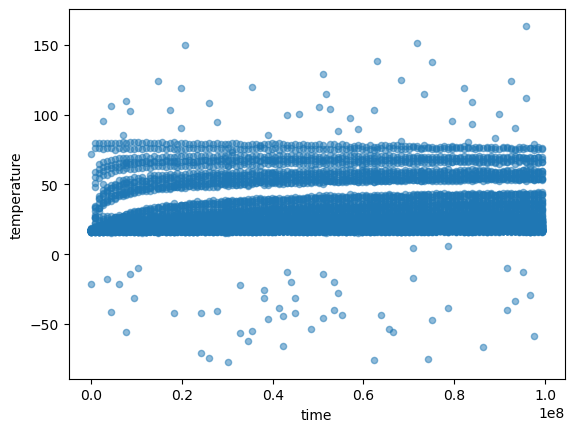

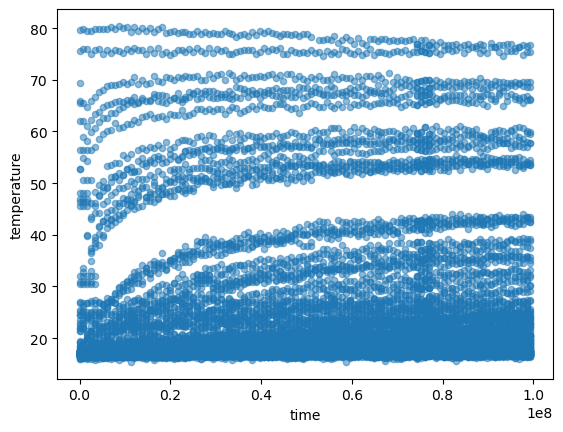

In [54]:
# Reading data
training_data=pd.read_parquet("data_parquet_2026/train.parquet").set_index(keys= "sensor")
sensors = pd.read_parquet("data_parquet_2026/sensors.parquet").drop(columns=["coor_z"]).drop_duplicates().set_index(keys= "sensor")
test_data = pd.read_parquet("data_parquet_2026/test.parquet").set_index(keys= "sensor")

"""Dropping the test sensors, as we will train the model only with the training data"""
test_sensors = test_data.index.unique()
train_sensors = sensors.drop(test_sensors)



"""---------------------------------------------------------------------
Sampling for TESTING ON SMALLER SETS"""
train_sensors = train_sensors.sample(frac = 1/5) # 20% des sensors
training_data = training_data.loc[train_sensors.index].query('time < 1e8') # 1% des times
"""---------------------------------------------------------------------"""



"""Partition of the training_data into our "training" and "validation" model's sets""" 
# Validation/ train coordinates' sets partition, over the train_sensors_set
validation_sensors_coo = train_sensors.sample(frac = 1/5)
train_sensors_coo = train_sensors.drop(labels=validation_sensors_coo.index)

# Validation/ train values' sets partition, ignoring unknown data of validation,
# and replacing them in training set
validation_samples_with_temp = training_data.loc[validation_sensors_coo.index].dropna()

training_data.drop(validation_sensors_coo.index).query('time < 1e8').plot.scatter(x="time", y="temperature", alpha=0.5)
train_samples_with_temp = preprocessing(training_data.drop(validation_sensors_coo.index))
train_samples_with_temp.plot.scatter(x="time", y="temperature", alpha=0.5)

# We "forget" the temperature values of the validation set
validation_samples = validation_samples_with_temp.drop(columns=["temperature"])

# Initialisation of neighbors_dict, which will stock the rows of the sensors with their scores
# to each given sample already evaluated.
neighbors_dict = {}


"""Let's train our model!"""

for k in range(5,10):
    validation_samples_with_pred = prediction(
        validation_set_coo = validation_sensors_coo,
        validation_set_times = validation_samples,
        train_set_coo = train_sensors_coo,
        train_set_values = train_samples_with_temp,
        distance_fn = eucli_dist, 
        k = k)
    

    """Let's evaluate it!"""
    get_loss = loss(
        ground_truths = validation_samples_with_temp,
        prediction_set= validation_samples_with_pred)
    
    print(f"Value of k: {k} \n Loss: {get_loss} \n --------- \n")
    


## II. A few improvements

### 1. Outliers Manager V2

In [ ]:
"""NOTE: We may clean multiple times same sensors but we don't care (multiple times neighbors)"""

def preprocessing_with_KNN(sensors_set: pd.DataFrame, sensors_coo: pd.DataFrame, k: int = 10, margin: float = 10) -> pd.DataFrame:

    """The global function to preprocess the Data. It first calls first_clean to delete
    'extreme' outliers, than clean the dataset by looking at the k-neighbors of a sample,
    and computing the median of their temperatures at given time to determine wether to
    keep or not the sample and neighbors' temperature.
    Args:
        sensors_set: dataset of all sensors to preprocess, with values of time,
         power and temperature.
        sensors_coo: dataset of the sensors' coordinates
        k: number of nearest neighbors considered, set to 10 by default
        margin: size of the safe zone, where the values are kept around the median.
    Returns:
        sensors_set: with cleaner data
    """

    # Deleting values of the dumb sensors
    sensors_set = first_clean(sensors_set = sensors_set)

    # We will check if each sample taken was a former neighbor of another, so we pass it.
    already_clean = np.array([])


    for sample in sensors_set["sensor"].unique(): # We pick every specific sensor of the dataset

        if sample in already_clean:
            continue

        # Here, the sample is counted as its own neighbor (distance == 0)
        neighbors = find_nearest_neighbors(
            sample_coo = sensors_coo["sensor" == sample], 
            train_set_coo = sensors_coo, 
            distance_fn = eucli_dist, 
            k = k + 1)

        ... # Add a line to pick each peculiar power

        for t in range(sensors_set["sensor" == sample].shape[0]):
            rows = sensors_set["sensor" == neighbors.sensor and "time" == t*864000]  # and "power" == power
            rows = window_cleaning(rows=rows, margin=margin)
        
        already_clean = np.concatenate((already_clean, neighbors["sensor"]), axis = 0)
        already_clean = np.unique(already_clean) # Deletes copies

    return sensors_set

### 2. n-Folder Validation


### Application

## III. Second model: Linear Regression

### 1. Prediction Function

### 2. Penalized Loss Function

### 3. Gradient Descent

### Application

## Tests post-fonctions

In [ ]:
for i in training_data.head(5)["temperature"].to_numpy:
    print(i)

"""sampleN418.isna().sum()
a=managing_missing_val(sampleN418)
a.isna().sum()
"""


In [ ]:
"""Test of the functions"""
train_data_expl = pd.DataFrame(data=np.array([[1,1,2,2,3,3,4,4,5,0],
                                     [1,3,2,4,1,3,2,4,0,5]]).T,
                                       columns=["coor_x","coor_y"], dtype='float64')
train_data_expl["sensor"] = ["N1","N2","N3","N4","N5","N6","N7","N8","N9","N10"]


test_data_expl = pd.DataFrame(data=np.array([[1.5,4.,4.5],
                                     [1.5,0.5,3.]]).T,
                                       columns=["coor_x","coor_y"], dtype = 'float64')
test_data_expl["sensor"] = ["N11","N12","N13"]

for _, sample in test_data_expl.iterrows():
  print(sample)
  print(eucli_dist(sample, train_data_expl))